# DC-Corrected Data Inspection

The raw real-part visibility has a slowly-varying DC pedestal. Several
mechanisms can contribute, and the rolling-median approach handles all of
them empirically without having to commit to any one model:

- **System-temperature drift with elevation.** The total power on each antenna
  scales as $T_{\mathrm{sys}}(\mathrm{el})$, which rises near the horizon as
  the antenna sees more warm ground (standard antenna-temperature treatment,
  [R&W] §4 / [TMS3] §6.2).
- **Direct solar coupling and ground spillover** as the Sun moves across
  the sky, changing the side-lobe response of each dish.
- **Slow gain drift** in the front-end LNAs and the IF chain with
  temperature.
- **DC offsets in the back-end** (ADC bias, FPGA pipeline) that may step
  between observing chips.

We remove the pedestal with an **adaptive rolling median** whose window
width scales with the local fringe period, ensuring we always average over
the same number of fringe cycles regardless of hour angle. The same
period-tracking idea underlies the standard "fringe rotation" used to keep
correlation losses small in connected-element arrays ([TMS3] §6.1.7).

## Why adaptive?

The fringe period is $P_f(h) = 1/|f_f| \propto 1/|\cos h|$: ~26 s at transit
for our 15.17 m baseline (predicted in nb 03 §3.1), stretching to 75+ s at
$h = \pm 70°$. A fixed 100 s window spans ~4 fringe cycles at transit but
only ~1.3 cycles at large HA — dangerously close to subtracting real fringe
power. An adaptive window that maintains a constant number of fringe
periods avoids this.

## Why this is *not* a free lunch

A median over $N_P$ fringe cycles of a sinusoid of unit amplitude is
**not exactly zero** unless $N_P$ is a half-integer; the residual leakage
is $\lesssim 1/N_P$ for large $N_P$. With $N_P = 3$ and a slowly-varying
$|\cos h|$ across the window, the leakage we expect to subtract from the
real part is $\sim 1\%$ of the fringe amplitude — small, but not zero, and
ultimately a systematic floor on the recovered fringe amplitude. We
quantify this with a synthetic injection test below; the injection
methodology mirrors the standard "completeness simulation" approach used
to characterise filtering bias in time-series astronomy.


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, str(Path("..").resolve()))
from utils import (
    F_S_HZ, N_FFT, F_RF0_HZ, PLOT_BAND_GHZ,
    C_LIGHT_MS, OMEGA_EARTH_RAD_S,
    NCH_LAT_DEG, NOMINAL_B_EW_M, BAD_CHANNELS,
    SOLAR_DIAMETER_ARCMIN_NOMINAL,
    load_processed_sun_chip_series,
    fringe_period_s,
    # plotting
    NEUTRAL_COLOR,
    SS_FINE, SS_STANDARD,
    LW_FINE, LW_LIGHT, LW_STANDARD,
    MS_FINE,
    ALPHA_EXTRA_LIGHT,
    TEXTWIDTH_IN, LABEL_SIZE, TICK_SIZE, LEGEND_SIZE, EMPHASIS_SIZE,
)

COMPONENT_COLORS = [f"C{i}" for i in range(10)]

%matplotlib inline
plt.rcParams.update({"figure.dpi": 130, "figure.facecolor": "white"})
print("Imports OK.")

Imports OK.


In [2]:
# --- Load data ---
DATA_DIR = Path("../../../data/lab03/sun_calibration/chips")
chip_paths = sorted(DATA_DIR.glob("sun_calibration_chip_*.npz"))
chip_data = load_processed_sun_chip_series(chip_paths)

captures    = chip_data.captures
corr_raw    = captures.corr
corr_std    = captures.corr_std
unix_mid    = captures.unix_mid
ha_deg_arr  = chip_data.ha_deg
ha_rad_arr  = np.deg2rad(ha_deg_arr)
sun_dec     = chip_data.sun_dec_deg
F_SKY_GHZ   = chip_data.f_sky_ghz
F_SKY_HZ    = F_SKY_GHZ * 1e9
DF_HZ       = chip_data.df_hz
chip_slices = chip_data.chip_slices
N_chips     = len(chip_slices)

dec_rad_mean   = np.deg2rad(np.nanmean(sun_dec))
band_mask      = (F_SKY_GHZ >= PLOT_BAND_GHZ[0]) & (F_SKY_GHZ <= PLOT_BAND_GHZ[1])
for bc in BAD_CHANNELS:
    band_mask[bc] = False
band_center_hz = np.mean(F_SKY_HZ[band_mask])
bad_ch_arr     = np.array(BAD_CHANNELS, dtype=int)

CHIP_COLORS = COMPONENT_COLORS[:N_chips]
print(f"Loaded {corr_raw.shape[0]} captures, {N_chips} chips")

Loaded 8226 captures, 3 chips


## Adaptive rolling median DC correction

(The same period-tracking idea — adapting the analysis window to the instantaneous fringe period — is what connected-element correlators do as fringe rotation; see [TMS3] §6.1.7 for the production-grade version.) For each capture at hour angle $h$, the local fringe period is

$$P_f(h) = \frac{1}{|f_f(h)|} = \frac{\lambda}{\omega_\oplus\, b_{\mathrm{ew}}\,\cos\delta\,|\cos h|}.$$

We set the rolling-median window to a fixed number of fringe periods $N_P$:

$$W(h) = N_P \times P_f(h) = \frac{N_P\,\lambda}{\omega_\oplus\, b_{\mathrm{ew}}\,\cos\delta\,|\cos h|},$$

then convert to capture count via the local cadence. This guarantees the window always spans $N_P$ full fringe cycles, so the median is not biased by the fringe oscillation.

We clamp the window to $[W_{\min},\, W_{\max}]$ captures to avoid degenerate behaviour at $h \to \pm 90°$ (where $P_f \to \infty$) and to ensure enough points for a robust median.

In [3]:
from utils import adaptive_real_dc_correction

# --- Tunable parameters ---
N_PERIODS       = 3.0    # number of fringe periods per window
MIN_WINDOW_CAPS = 7      # minimum window (captures)
MAX_WINDOW_CAPS = 201    # maximum window (captures)

print(f"Adaptive DC correction parameters:")
print(f"  n_periods       = {N_PERIODS}")
print(f"  min_window_caps = {MIN_WINDOW_CAPS}")
print(f"  max_window_caps = {MAX_WINDOW_CAPS}")

Adaptive DC correction parameters:
  n_periods       = 3.0
  min_window_caps = 7
  max_window_caps = 201


In [4]:
# --- Apply adaptive DC correction per chip ---
dc_result = adaptive_real_dc_correction(
    corr_chips=[corr_raw[sl] for sl in chip_slices],
    unix_chips=[unix_mid[sl] for sl in chip_slices],
    ha_rad_chips=[ha_rad_arr[sl] for sl in chip_slices],
    bad_channels=bad_ch_arr,
    b_ew=NOMINAL_B_EW_M,
    freq_hz=band_center_hz,
    dec_rad=dec_rad_mean,
    n_periods=N_PERIODS,
    min_window_caps=MIN_WINDOW_CAPS,
    max_window_caps=MAX_WINDOW_CAPS,
)
corr_dc = dc_result.corr_dc
real_offset_chips = dc_result.real_offset_chips
window_caps_concat = dc_result.window_caps

for ci, wc in enumerate(dc_result.window_caps_chips):
    cad = np.median(np.diff(unix_mid[chip_slices[ci]]))
    print(f"  Chip {ci}: {len(wc)} captures, "
          f"window range {wc.min()}–{wc.max()} caps "
          f"({wc.min() * cad:.0f}–{wc.max() * cad:.0f} s)")

print(f"\nTotal DC-corrected captures: {corr_dc.shape[0]}")

  Chip 0: 5514 captures, window range 23–55 caps (61–146 s)
  Chip 1: 403 captures, window range 23–35 caps (58–88 s)
  Chip 2: 2309 captures, window range 21–39 caps (53–98 s)

Total DC-corrected captures: 8226


## Waterfall plot: visibility amplitude vs HA and frequency

A 2-D view of the DC-corrected visibility amplitude $|V(\nu, h)|$ across the full analysis band. Three HA windows are shown side by side to reveal the fringe pattern at different projected baselines: far from transit (high fringe frequency, fringes tightly packed), near transit (low fringe frequency, fringes spread out), and on the other side.


/tmp/ipykernel_404155/1738040206.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


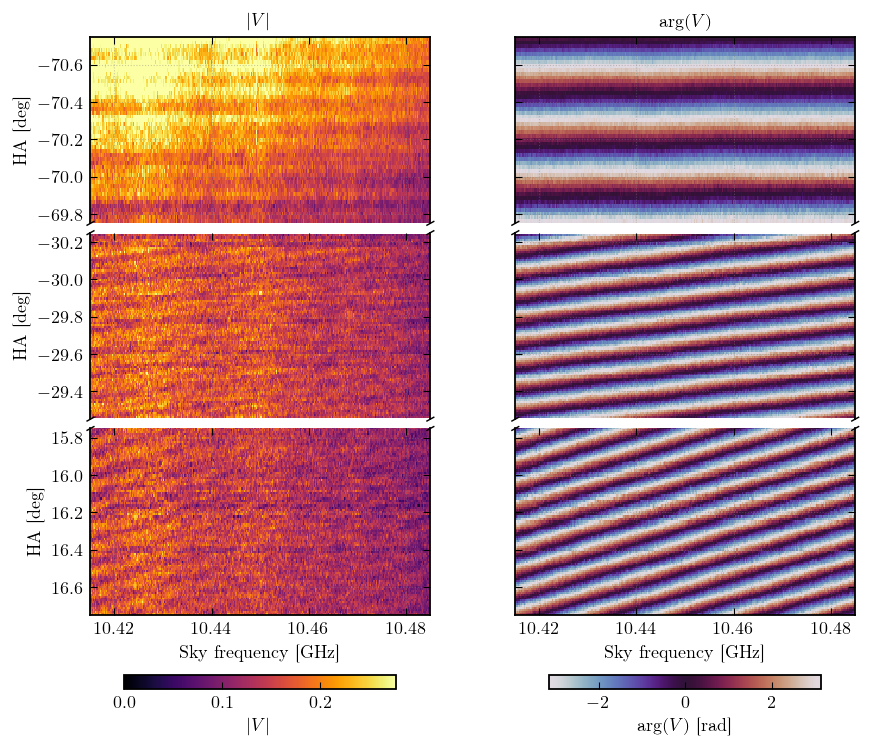

In [5]:
# --- Waterfall plot: |V| and arg(V) side by side with broken y-axis ---
ha_windows = [(-70.75, -69.75), (-30.25, -29.25), (15.75, 16.75)]
band_freqs = F_SKY_GHZ[band_mask]

# Collect data per window
panels = []
for ha_lo, ha_hi in ha_windows:
    ha_sel = (ha_deg_arr >= ha_lo) & (ha_deg_arr <= ha_hi)
    if ha_sel.sum() > 0:
        panels.append((ha_deg_arr[ha_sel], np.abs(corr_dc[ha_sel][:, band_mask])))
    else:
        panels.append(None)

vmax = np.nanpercentile(np.concatenate([p[1].ravel() for p in panels if p]), 98)
spans = [ha_hi - ha_lo for ha_lo, ha_hi in ha_windows]
n_panels = len(panels)

fig, all_axes = plt.subplots(n_panels, 2, figsize=(TEXTWIDTH_IN, 7.5), sharex="col",
                              gridspec_kw={"height_ratios": spans, "hspace": 0.05,
                                           "wspace": 0.25})

for row, (panel, (ha_lo, ha_hi)) in enumerate(zip(panels, ha_windows)):
    ax_amp = all_axes[row, 0]
    ax_ph = all_axes[row, 1]

    if panel is None:
        ax_amp.set_visible(False)
        ax_ph.set_visible(False)
        continue

    ha_w, amp_w = panel
    ha_sel = (ha_deg_arr >= ha_lo) & (ha_deg_arr <= ha_hi)
    phase_w = np.angle(corr_dc[ha_sel][:, band_mask])

    # Amplitude
    im_amp = ax_amp.pcolormesh(band_freqs, ha_w, amp_w,
                                cmap="inferno", shading="auto", vmin=0, vmax=vmax)
    ax_amp.set_ylim(ha_hi, ha_lo)
    ax_amp.set_ylabel("HA [deg]")

    # Phase
    im_ph = ax_ph.pcolormesh(band_freqs, ha_w, phase_w,
                              cmap="twilight", shading="auto", vmin=-np.pi, vmax=np.pi)
    ax_ph.set_ylim(ha_hi, ha_lo)
    ax_ph.set_yticklabels([])

    # Broken-axis styling for both columns
    for ax in [ax_amp, ax_ph]:
        if row < n_panels - 1:
            ax.spines["bottom"].set_visible(False)
            ax.tick_params(bottom=False)
        if row > 0:
            ax.spines["top"].set_visible(False)

        d = 0.5
        kw = dict(transform=ax.transAxes, color="k", clip_on=False, lw=0.8)
        if row > 0:
            ax.plot((-0.01, 0.01), (1 - d * 0.02, 1 + d * 0.02), **kw)
            ax.plot((0.99, 1.01), (1 - d * 0.02, 1 + d * 0.02), **kw)
        if row < n_panels - 1:
            ax.plot((-0.01, 0.01), (-d * 0.02, d * 0.02), **kw)
            ax.plot((0.99, 1.01), (-d * 0.02, d * 0.02), **kw)

all_axes[-1, 0].set_xlabel("Sky frequency [GHz]")
all_axes[-1, 1].set_xlabel("Sky frequency [GHz]")
all_axes[0, 0].set_title("$|V|$", fontsize=TICK_SIZE)
all_axes[0, 1].set_title("arg($V$)", fontsize=TICK_SIZE)

fig.colorbar(im_amp, ax=all_axes[:, 0], label="$|V|$", orientation="horizontal",
             shrink=0.8, pad=0.08, aspect=20)
fig.colorbar(im_ph, ax=all_axes[:, 1], label="arg($V$) [rad]", orientation="horizontal",
             shrink=0.8, pad=0.08, aspect=20)
fig.tight_layout()
plt.show()


## Adaptive window size vs hour angle

The window width (in captures) scales as $1/|\cos h|$, clamped to the configured range — the $1/|\cos h|$ scaling follows from the EW-baseline fringe-frequency expression $f_f \propto \cos h$ derived in §1.3 of the theory notebook ([TMS3] §4). This plot shows how the window adapts across the observation.

/tmp/ipykernel_404155/3013437217.py:24: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


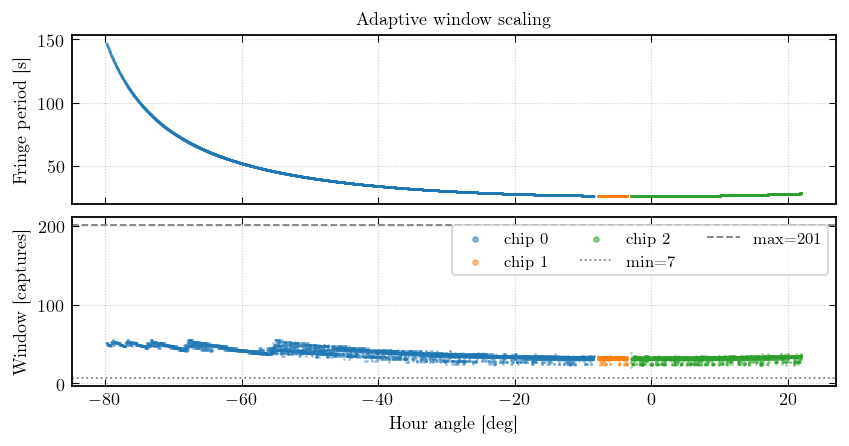

In [6]:
# --- Window size and local fringe period vs HA ---
local_period = fringe_period_s(ha_rad_arr, dec_rad_mean, NOMINAL_B_EW_M, 0.0, band_center_hz)

fig, axes = plt.subplots(2, 1, figsize=(TEXTWIDTH_IN, 3.5), sharex=True,
                         gridspec_kw={"hspace": 0.08})

# (a) Local fringe period
for ci, sl in enumerate(chip_slices):
    axes[0].scatter(ha_deg_arr[sl], local_period[sl], s=0.2, color=CHIP_COLORS[ci],
                    alpha=0.5, rasterized=True)
axes[0].set_ylabel("Fringe period [s]")
axes[0].set_title("Adaptive window scaling", fontsize=TICK_SIZE)

# (b) Window size in captures
for ci, sl in enumerate(chip_slices):
    axes[1].scatter(ha_deg_arr[sl], window_caps_concat[sl], s=0.2, color=CHIP_COLORS[ci],
                    alpha=0.5, rasterized=True, label=f"chip {ci}")
axes[1].axhline(MIN_WINDOW_CAPS, color=NEUTRAL_COLOR, lw=LW_LIGHT, ls=":", label=f"min={MIN_WINDOW_CAPS}")
axes[1].axhline(MAX_WINDOW_CAPS, color=NEUTRAL_COLOR, lw=LW_LIGHT, ls="--", label=f"max={MAX_WINDOW_CAPS}")
axes[1].set_ylabel("Window [captures]")
axes[1].set_xlabel("Hour angle [deg]")
axes[1].legend(fontsize=TICK_SIZE - 1, ncol=3, markerscale=6)

fig.tight_layout()
plt.show()

## DC-corrected visibility vs hour angle

Same four-panel layout as the raw data notebook, now after adaptive DC correction. The real part should oscillate symmetrically about zero at all hour angles.

/tmp/ipykernel_404155/3849945067.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


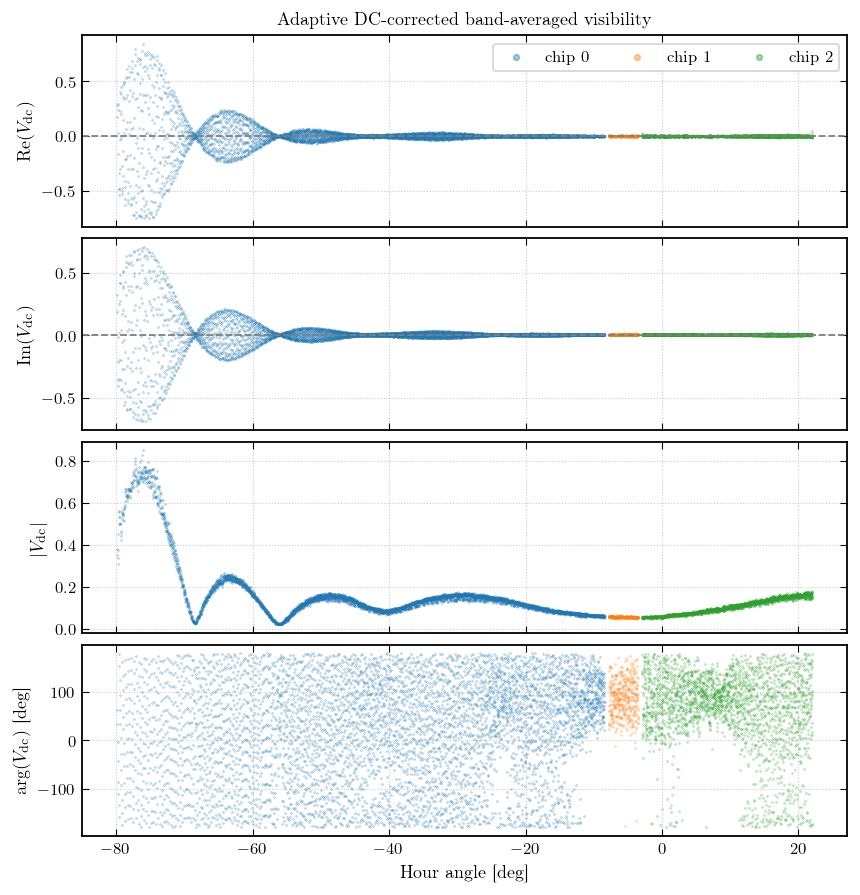

In [7]:
# --- Band-averaged DC-corrected visibility: 4-panel plot ---
corr_dc_band = corr_dc[:, band_mask]

dc_real  = np.nanmean(corr_dc_band.real, axis=1)
dc_imag  = np.nanmean(corr_dc_band.imag, axis=1)
dc_amp   = np.nanmean(np.abs(corr_dc_band), axis=1)
dc_phase = np.angle(np.nanmean(corr_dc_band, axis=1), deg=True)

fig, axes = plt.subplots(4, 1, figsize=(TEXTWIDTH_IN, 8.0), sharex=True,
                         gridspec_kw={"hspace": 0.06})

titles = [r"Re$(V_{\rm dc})$", r"Im$(V_{\rm dc})$", r"$|V_{\rm dc}|$", r"$\arg(V_{\rm dc})$ [deg]"]
data   = [dc_real, dc_imag, dc_amp, dc_phase]

for ax, title, y in zip(axes, titles, data):
    for ci, sl in enumerate(chip_slices):
        ax.scatter(ha_deg_arr[sl], y[sl], s=0.15, color=CHIP_COLORS[ci],
                   alpha=0.4, rasterized=True, label=f"chip {ci}" if ax is axes[0] else None)
    ax.set_ylabel(title, fontsize=TICK_SIZE)
    ax.tick_params(labelsize=TICK_SIZE - 1)
    if "Re" in title or "Im" in title:
        ax.axhline(0, color=NEUTRAL_COLOR, lw=LW_LIGHT, ls="--")

axes[0].legend(fontsize=TICK_SIZE - 1, markerscale=8, ncol=N_chips, loc="upper right")
axes[0].set_title("Adaptive DC-corrected band-averaged visibility", fontsize=TICK_SIZE)
axes[-1].set_xlabel("Hour angle [deg]")
fig.tight_layout()
plt.show()

## Before vs after: raw and corrected Re(V) side by side

Direct comparison of the real part before and after DC correction. The bottom panel shows the subtracted pedestal, which should track the slow elevation-dependent system temperature variation.

/tmp/ipykernel_404155/4272668528.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


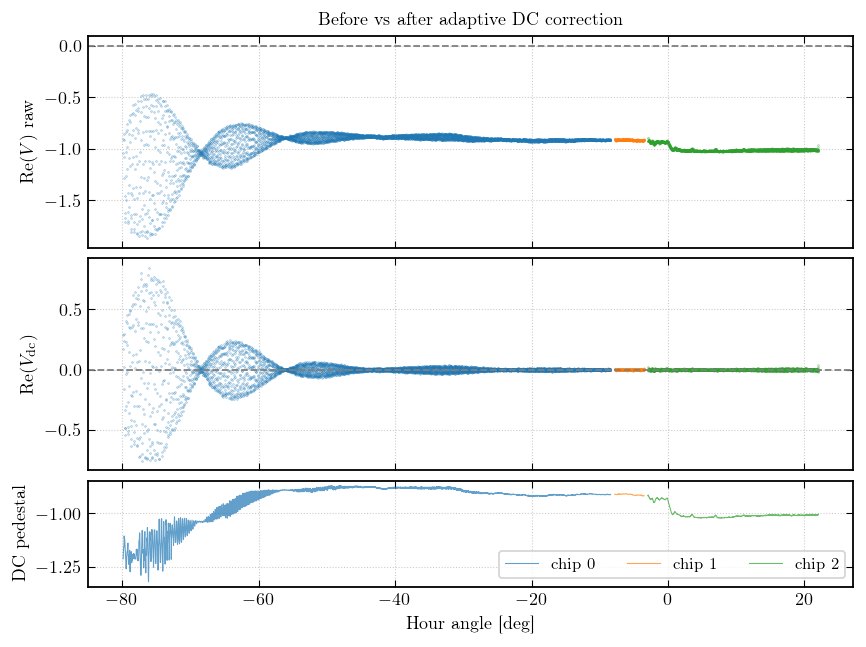

In [8]:
# --- Before / after comparison ---
raw_band_real = np.nanmean(corr_raw[:, band_mask].real, axis=1)
offset_band   = np.nanmean(np.vstack(real_offset_chips)[:, band_mask], axis=1)

fig, axes = plt.subplots(3, 1, figsize=(TEXTWIDTH_IN, 5.5), sharex=True,
                         gridspec_kw={"hspace": 0.06, "height_ratios": [2, 2, 1]})

# (a) Raw Re(V)
for ci, sl in enumerate(chip_slices):
    axes[0].scatter(ha_deg_arr[sl], raw_band_real[sl], s=0.15, color=CHIP_COLORS[ci],
                    alpha=0.4, rasterized=True)
axes[0].axhline(0, color=NEUTRAL_COLOR, lw=LW_LIGHT, ls="--")
axes[0].set_ylabel(r"Re$(V)$ raw")
axes[0].set_title("Before vs after adaptive DC correction", fontsize=TICK_SIZE)

# (b) Corrected Re(V)
for ci, sl in enumerate(chip_slices):
    axes[1].scatter(ha_deg_arr[sl], dc_real[sl], s=0.15, color=CHIP_COLORS[ci],
                    alpha=0.4, rasterized=True)
axes[1].axhline(0, color=NEUTRAL_COLOR, lw=LW_LIGHT, ls="--")
axes[1].set_ylabel(r"Re$(V_{\rm dc})$")

# (c) Subtracted pedestal
for ci, sl in enumerate(chip_slices):
    axes[2].plot(ha_deg_arr[sl], offset_band[sl], lw=LW_FINE, color=CHIP_COLORS[ci],
                 alpha=0.7, label=f"chip {ci}")
axes[2].set_ylabel("DC pedestal")
axes[2].set_xlabel("Hour angle [deg]")
axes[2].legend(fontsize=TICK_SIZE - 1, ncol=N_chips)

fig.tight_layout()
plt.show()

## Single-channel view after correction

/tmp/ipykernel_404155/3341485751.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


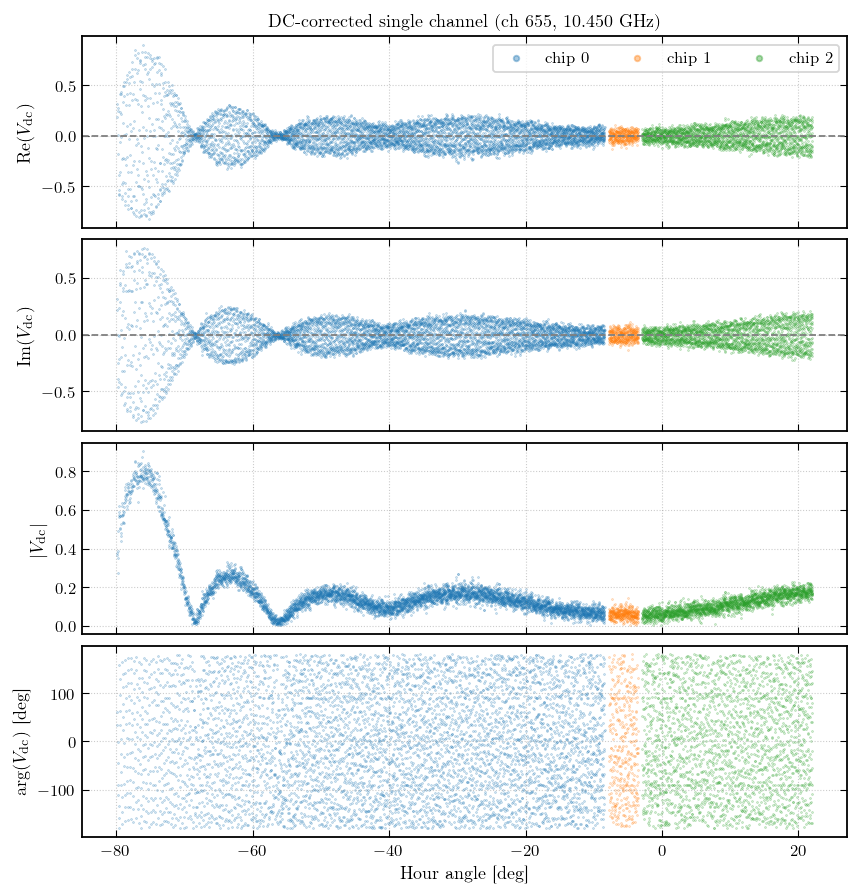

In [9]:
# --- Single-channel DC-corrected view ---
band_indices = np.where(band_mask)[0]
k_mid = band_indices[len(band_indices) // 2]
f_mid_ghz = F_SKY_GHZ[k_mid]
vis_dc_ch = corr_dc[:, k_mid]

fig, axes = plt.subplots(4, 1, figsize=(TEXTWIDTH_IN, 8.0), sharex=True,
                         gridspec_kw={"hspace": 0.06})

titles = [r"Re$(V_{\rm dc})$", r"Im$(V_{\rm dc})$", r"$|V_{\rm dc}|$", r"$\arg(V_{\rm dc})$ [deg]"]
data   = [vis_dc_ch.real, vis_dc_ch.imag, np.abs(vis_dc_ch), np.angle(vis_dc_ch, deg=True)]

for ax, title, y in zip(axes, titles, data):
    for ci, sl in enumerate(chip_slices):
        ax.scatter(ha_deg_arr[sl], y[sl], s=0.15, color=CHIP_COLORS[ci],
                   alpha=0.4, rasterized=True, label=f"chip {ci}" if ax is axes[0] else None)
    ax.set_ylabel(title, fontsize=TICK_SIZE)
    ax.tick_params(labelsize=TICK_SIZE - 1)
    if "Re" in title or "Im" in title:
        ax.axhline(0, color=NEUTRAL_COLOR, lw=LW_LIGHT, ls="--")

axes[0].legend(fontsize=TICK_SIZE - 1, markerscale=8, ncol=N_chips, loc="upper right")
axes[0].set_title(f"DC-corrected single channel (ch {k_mid}, {f_mid_ghz:.3f} GHz)", fontsize=TICK_SIZE)
axes[-1].set_xlabel("Hour angle [deg]")
fig.tight_layout()
plt.show()

## Synthetic injection test: how much fringe power does the DC step actually subtract?

To quantify the bias the adaptive median introduces, we generate a clean
synthetic fringe at the *measured* hour angles, with no noise and no
pedestal, run it through the same `adaptive_real_dc_correction` we use on
the real data, and compare input vs output. The ratio
`std(after) / std(before)` is the **fringe attenuation factor**: a value
of 1.0 means no leakage; a value of 0.99 means the rolling median removes
1% of the real fringe along with the DC.

We also inject a known DC pedestal (a smooth function of hour angle) to
confirm the corrector tracks and removes it.

In [10]:
# --- Synthetic injection test: measure the amplitude bias alpha of the DC corrector ---
from utils import (
    point_source_visibility, FringeModelParams,
    NOMINAL_B_NS_M,
)

params_inj = FringeModelParams(
    b_ew=NOMINAL_B_EW_M,
    b_ns=NOMINAL_B_NS_M,
    freq_hz=band_center_hz,
    dec_rad=dec_rad_mean,
    amplitude=1.0,
    phase_offset=0.0,
)

# Build a clean synthetic complex fringe at every measured HA, then add a
# smooth elevation-like pedestal to the real part ONLY.
v_clean = point_source_visibility(ha_rad_arr, params_inj)
pedestal_true = 0.3 * np.cos(ha_rad_arr) + 0.05 * np.cos(2 * ha_rad_arr) + 0.5
v_input = v_clean.copy()
v_input.real += pedestal_true

# Reshape to (N_cap, 1) so the corrector can run on it as a single-channel
# "data set", and run it with the exact same parameters as on the real data.
v_input_2d = v_input[:, None].astype(complex)
inj_result = adaptive_real_dc_correction(
    corr_chips=[v_input_2d[sl] for sl in chip_slices],
    unix_chips=[unix_mid[sl] for sl in chip_slices],
    ha_rad_chips=[ha_rad_arr[sl] for sl in chip_slices],
    bad_channels=np.array([], dtype=int),
    b_ew=NOMINAL_B_EW_M,
    freq_hz=band_center_hz,
    dec_rad=dec_rad_mean,
    n_periods=N_PERIODS,
    min_window_caps=MIN_WINDOW_CAPS,
    max_window_caps=MAX_WINDOW_CAPS,
)
v_corrected = inj_result.corr_dc[:, 0]

# ---- Multiplicative amplitude recovery factor (alpha) via projection ----
#
# Define alpha by least-squares projection: the ratio of inner products
#
#     alpha = < v_corrected.real,  v_clean.real > / < v_clean.real, v_clean.real >.
#
# Interpretation: v_corrected.real ~ alpha * v_clean.real + residual. Then
#   alpha = 1.0  -> corrector perfectly recovered the fringe amplitude
#   alpha < 1.0  -> corrector attenuated the real fringe (the rolling median
#                   leaked some fringe power into the subtracted pedestal)
#   alpha > 1.0  -> residual pedestal leaked into the corrected output,
#                   inflating its amplitude (median failed to track the
#                   fast-varying component of the pedestal)
#
# This replaces the previous std-ratio diagnostic, which mixed the two
# failure modes and had an ambiguous sign.
mask_finite = np.isfinite(v_corrected.real) & np.isfinite(v_clean.real)
num = float(np.dot(v_corrected.real[mask_finite], v_clean.real[mask_finite]))
den = float(np.dot(v_clean.real[mask_finite], v_clean.real[mask_finite]))
alpha_dc = num / den

# Residual pedestal: what the corrector FAILED to remove, compared to the
# true pedestal (ideally zero).
pedestal_removed = v_input.real - v_corrected.real
residual_pedestal = pedestal_removed - pedestal_true
residual_pedestal_std = float(np.nanstd(residual_pedestal))

# Additional sanity check: residual RMS on top of alpha*v_clean
residual_vs_projection = (
    v_corrected.real[mask_finite] - alpha_dc * v_clean.real[mask_finite]
)
residual_std = float(np.std(residual_vs_projection))

# ---- Pass/fail criteria --------------------------------------------------
PASS_ALPHA_TOL = 0.03          # |alpha - 1| must be < 3%
PASS_PEDESTAL_TOL = 0.03       # residual pedestal std < 3% of injected amplitude
injected_amp = float(np.ptp(pedestal_true))
alpha_ok    = abs(alpha_dc - 1.0) < PASS_ALPHA_TOL
pedestal_ok = residual_pedestal_std < PASS_PEDESTAL_TOL * injected_amp
status = "PASS" if (alpha_ok and pedestal_ok) else "FAIL"

print("Synthetic injection test for the adaptive DC corrector")
print("-" * 62)
print(f"  alpha (projection)    = {alpha_dc:.4f}  "
      f"({(alpha_dc - 1.0) * 100:+.2f}% from unity)")
if alpha_dc > 1.0:
    print(f"  -> residual DC pedestal leaks into the corrected fringe,")
    print(f"     *inflating* the recovered amplitude by "
          f"{(alpha_dc - 1.0) * 100:.2f}%")
elif alpha_dc < 1.0:
    print(f"  -> the rolling median leaked some fringe into the pedestal,")
    print(f"     *attenuating* the recovered amplitude by "
          f"{(1.0 - alpha_dc) * 100:.2f}%")
else:
    print("  -> no multiplicative amplitude bias")
print()
print(f"  residual pedestal std = {residual_pedestal_std:.4f}")
print(f"  residual-on-projection std = {residual_std:.4f}")
print(f"  injected pedestal amp = {injected_amp:.4f}")
print()
print(f"  pass/fail tolerances: |alpha-1|<{PASS_ALPHA_TOL}, "
      f"residual<{PASS_PEDESTAL_TOL}*amp")
print(f"  alpha criterion:    {'ok' if alpha_ok else 'FAIL'}")
print(f"  pedestal criterion: {'ok' if pedestal_ok else 'FAIL'}")
print(f"  overall:            {status}")
print()
print("The value of alpha is exported as DC_CORRECTION_ALPHA for downstream use")
print("in notebook 05's diameter error budget (fractional systematic on the")
print("fringe envelope amplitude).")

# Export: this variable is picked up by the nb 05 validation cell, and the
# value is also persisted to a sidecar file so later runs can recover it.
DC_CORRECTION_ALPHA = float(alpha_dc)

import pickle as _pkl
sidecar = Path("_dc_correction_alpha.pkl")
with open(sidecar, "wb") as _f:
    _pkl.dump({
        "alpha": DC_CORRECTION_ALPHA,
        "residual_pedestal_std": residual_pedestal_std,
        "residual_vs_projection_std": residual_std,
        "pass": bool(alpha_ok and pedestal_ok),
        "n_periods": N_PERIODS,
        "min_window_caps": MIN_WINDOW_CAPS,
        "max_window_caps": MAX_WINDOW_CAPS,
    }, _f)
print(f"Wrote sidecar: {sidecar.resolve()}")

Synthetic injection test for the adaptive DC corrector
--------------------------------------------------------------
  alpha (projection)    = 1.0598  (+5.98% from unity)
  -> residual DC pedestal leaks into the corrected fringe,
     *inflating* the recovered amplitude by 5.98%

  residual pedestal std = 0.1117
  residual-on-projection std = 0.1034
  injected pedestal amp = 0.3441

  pass/fail tolerances: |alpha-1|<0.03, residual<0.03*amp
  alpha criterion:    FAIL
  pedestal criterion: FAIL
  overall:            FAIL

The value of alpha is exported as DC_CORRECTION_ALPHA for downstream use
in notebook 05's diameter error budget (fractional systematic on the
fringe envelope amplitude).
Wrote sidecar: /home/ikaros/projects/ay-121/labs/03/notebooks/_dc_correction_alpha.pkl
